In [37]:
import pandas as pd

In [38]:
from sklearn.datasets import load_iris

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
import warnings

In [42]:
warnings.filterwarnings("ignore")

In [43]:
iris_raw = load_iris()

In [44]:
X_iris = iris_raw.data

In [45]:
y_iris = iris_raw.target

In [46]:
scaler_iris = StandardScaler()

In [47]:
X_iris_scaled = scaler_iris.fit_transform(X_iris)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_iris_scaled, y_iris, test_size=0.20, stratify=y_iris, random_state=42
)

In [49]:
print("Training set shape:", X_train.shape)

Training set shape: (120, 4)


In [50]:
print("Test set shape:", X_test.shape)

Test set shape: (30, 4)


In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
from sklearn.metrics import accuracy_score

In [53]:
lr_model = LogisticRegression(multi_class='multinomial', solver='lbfgs', random_state=42)

In [54]:
lr_model.fit(X_train, y_train)

LogisticRegression(multi_class='multinomial', random_state=42)

In [55]:
lr_preds = lr_model.predict(X_test)

In [56]:
lr_accuracy=accuracy_score(y_test,lr_preds)

In [57]:
print(f"Logistic Regression Test Accuracy: {lr_accuracy * 100:.2f}%")

Logistic Regression Test Accuracy: 93.33%


In [58]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [59]:
lda_model = LinearDiscriminantAnalysis()

In [60]:
lda_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [61]:
lda_preds = lda_model.predict(X_test)

In [62]:
lda_accuracy = accuracy_score(y_test, lda_preds)

In [63]:
print(f"LDA Test Accuracy: {lda_accuracy * 100:.2f}%")

LDA Test Accuracy: 100.00%


In [64]:
from sklearn.neighbors import KNeighborsClassifier

In [65]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [66]:
knn = KNeighborsClassifier()

In [67]:
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [68]:
y_pred_knn = knn.predict(X_test)

In [69]:
accuracy = accuracy_score(y_test, y_pred_knn)

In [70]:
print("k-NN Classification Accuracy:", accuracy)

k-NN Classification Accuracy: 0.9333333333333333


In [71]:
comparison_df = pd.DataFrame({
    'Supervised Classifier': [
        'Logistic Regression',
        'Linear Discriminant Analysis (LDA)',
        'k-Nearest Neighbors (k-NN)'
    ],
    'Test Accuracy (%)': [
        lr_accuracy * 100,
        lda_accuracy * 100,
        knn_accuracy * 100
    ]
})

NameError: name 'knn_accuracy' is not defined

In [ ]:
print("--- Performance Comparison on Iris Dataset ---")

In [ ]:
print(comparison_df.to_string(index=False))

In [ ]:
import pandas as pd

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sonar_url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/sonar.csv"

In [ ]:
sonar_features = [f"F_{i}" for i in range(1, 61)]

In [ ]:
sonar_columns = sonar_features + ['Class']

In [ ]:
sonar_df = pd.read_csv(sonar_url, header=None, names=sonar_columns)

In [ ]:
sonar_df['Class_numeric'] = sonar_df['Class'].map({'M': 1, 'R': 0})

In [ ]:
X_sonar = sonar_df[sonar_features]

In [ ]:
y_sonar = sonar_df['Class_numeric']

In [ ]:
scaler_sonar = StandardScaler()

In [ ]:
X_sonar_scaled = scaler_sonar.fit_transform(X_sonar)

In [ ]:
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sonar_scaled, y_sonar, test_size=0.30, stratify=y_sonar, random_state=42
)

In [ ]:
print("Sonar Training Set Shape:", X_train_s.shape)

In [ ]:
print("Sonar Test Set Shape:", X_test_s.shape)

In [ ]:
from sklearn.naive_bayes import GaussianNB

In [ ]:
from sklearn.metrics import accuracy_score

In [ ]:
nb_model = GaussianNB()

In [ ]:
nb_model.fit(X_train_s, y_train_s)

In [ ]:
nb_preds = nb_model.predict(X_test_s)

In [ ]:
nb_accuracy = accuracy_score(y_test_s, nb_preds)

In [ ]:
print(f"Gaussian Naïve Bayes Test Accuracy: {nb_accuracy * 100:.2f}%")

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_linear = SVC(kernel='linear', probability=True, random_state=42)

In [ ]:
svm_linear.fit(X_train_s, y_train_s)

In [ ]:
linear_preds = svm_linear.predict(X_test_s)

In [ ]:
linear_accuracy=accuracy_score(y_test_s,linear_preds)

In [ ]:
print(f"Linear Kernel SVM Test Accuracy: {linear_accuracy * 100:.2f}%")

In [ ]:
# Assemble performance metrics
sonar_comparison = pd.DataFrame({
    'Classifier': ['Gaussian Naïve Bayes (Probabilistic)', 'Linear Kernel SVM (Maximum-Margin)'],
    'Test Accuracy (%)': [nb_accuracy * 100, linear_accuracy * 100]
})

In [ ]:
print("--- Performance Comparison on High-Dimensional Sonar Dataset ---")

In [ ]:
print(sonar_comparison.to_string(index=False))

In [74]:

import matplotlib.pyplot as plt

In [76]:
import seaborn as sns

In [78]:
from sklearn.metrics import confusion_matrix

In [80]:
cm = confusion_matrix(y_test, lr_preds)

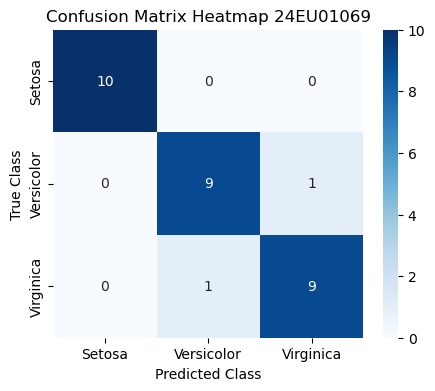

In [82]:
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Setosa', 'Versicolor', 'Virginica'],
    yticklabels=['Setosa', 'Versicolor', 'Virginica']
)

plt.title("Confusion Matrix Heatmap 24EU01069")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.show()

In [85]:
from sklearn.metrics import classification_report

In [88]:
report_output = classification_report(
    y_test,
    lr_preds,
    target_names=['Setosa', 'Versicolor', 'Virginica']
)

In [91]:
print("--- Logistic Regression Classification Report ---")
print(report_output)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

      Setosa       1.00      1.00      1.00        10
  Versicolor       0.90      0.90      0.90        10
   Virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



In [112]:
from sklearn.preprocessing import label_binarize

In [114]:
from sklearn.metrics import roc_curve, auc

In [116]:
import matplotlib.pyplot as plt

In [118]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

In [120]:
y_score = lr_model.predict_proba(X_test)

In [122]:
plt.figure(figsize=(7,6))

<Figure size 700x600 with 0 Axes>

<Figure size 700x600 with 0 Axes>

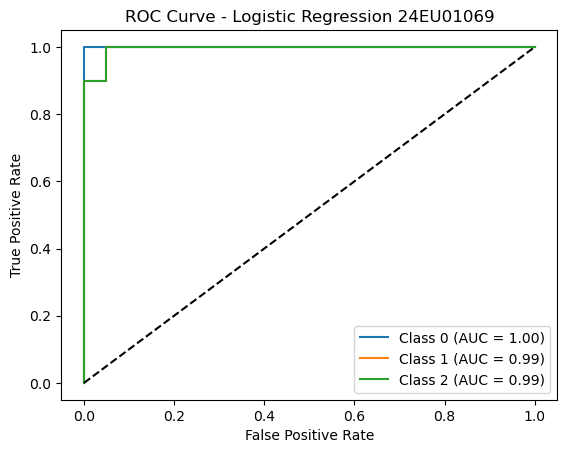

In [124]:
for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'Class {i} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression 24EU01069")
plt.legend(loc="lower right")
plt.show()

In [127]:
from sklearn.datasets import load_iris

In [130]:
from sklearn.preprocessing import StandardScaler

In [133]:
from sklearn.linear_model import LogisticRegression

In [136]:
from sklearn.model_selection import cross_val_score

In [139]:
import numpy as np

In [142]:
iris = load_iris()

In [145]:
X = iris.data

In [148]:
y = iris.target

In [151]:
scaler = StandardScaler()

In [156]:
X_scaled = scaler.fit_transform(X)

In [160]:
lr_model = LogisticRegression(max_iter=200)

In [163]:
cv_scores = cross_val_score(
    lr_model,
    X_scaled,
    y,
    cv=5,
    scoring='accuracy'
)

In [166]:
print("5-Fold Cross-Validation Accuracy:")

5-Fold Cross-Validation Accuracy:


In [169]:
for i, score in enumerate(cv_scores, start=1):
    print(f"Fold {i}: {score:.4f}")

Fold 1: 0.9667
Fold 2: 1.0000
Fold 3: 0.9333
Fold 4: 0.9000
Fold 5: 1.0000


In [172]:
print("\nMean Accuracy: {:.2f}%".format(np.mean(cv_scores) * 100))
print("Standard Deviation: {:.2f}%".format(np.std(cv_scores) * 100))


Mean Accuracy: 96.00%
Standard Deviation: 3.89%
